# **Setup**

- https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul 
- https://www.kaggle.com/code/pythonafroz/preventive-maintenance-of-industrial-motor 

- https://www.youtube.com/watch?v=0LtUxM8z_6Q 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# **Data Import**

In [2]:
!kaggle datasets download ignaciovinuales/battery-remaining-useful-life-rul

from zipfile import ZipFile
file_name = "battery-remaining-useful-life-rul.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('Done')

Dataset URL: https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul
License(s): CC0-1.0
battery-remaining-useful-life-rul.zip: Skipping, found more recently modified local copy (use --force to force download)
Done


In [3]:
df = pd.read_csv('Battery_RUL.csv',dtype={'Cycle_Index': int})

print(df.shape)
print(df.columns)

df.head()

(15064, 9)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [4]:
df.rename(columns={'Discharge Time (s)':'Discharge_Time'
                   ,'Decrement 3.6-3.4V (s)':'Decrement_Time'
                   ,'Max. Voltage Dischar. (V)': 'Max_Discharge_Voltage'
                   , 'Min. Voltage Charg. (V)': 'Min_Charge_Voltage'
                   ,'Time at 4.15V (s)':'Time_At_4_15V'
                   , 'Time constant current (s)': 'Const_Current_Time'
                   , 'Charging time (s)': 'Charging_Time'}
                   , inplace=True)

df.columns

Index(['Cycle_Index', 'Discharge_Time', 'Decrement_Time',
       'Max_Discharge_Voltage', 'Min_Charge_Voltage', 'Time_At_4_15V',
       'Const_Current_Time', 'Charging_Time', 'RUL'],
      dtype='object')

In [5]:
# Assign Battery ID
df['BatteryID'] = (df['Cycle_Index'] == 1).cumsum()

# Resequence Columns 
df = df.loc[:, ['BatteryID', 'Cycle_Index', 'Discharge_Time', 'Decrement_Time',
       'Max_Discharge_Voltage', 'Min_Charge_Voltage', 'Time_At_4_15V',
       'Const_Current_Time', 'Charging_Time', 'RUL']]

df[df['Cycle_Index'] == 1].head(14)

,BatteryID,Cycle_Index,Discharge_Time,Decrement_Time,Max_Discharge_Voltage,Min_Charge_Voltage,Time_At_4_15V,Const_Current_Time,Charging_Time,RUL
0,1,1,2595.30,1151.4885,3.670,3.211,5460.001,6755.01,10777.82,1112
1076,2,1,2604.00,1186.4955,3.666,3.213,5424.991,6706.02,10772.99,1107
2155,3,1,2562.02,1140.9910,3.666,3.219,5452.993,6740.99,10836.00,1107
3232,4,1,2566.08,1161.9830,3.667,3.214,5452.992,6740.99,10938.33,1107
4313,5,1,2590.02,1239.0070,3.660,3.225,5376.000,6678.01,10821.98,1133
5390,6,1,2609.47,1372.0000,3.650,3.228,5348.000,6678.02,11078.56,1102
6468,7,1,2590.98,1154.9760,3.667,3.224,5452.992,6727.01,10819.42,1107
7549,8,1,2590.50,1169.0240,3.667,3.206,5446.016,6734.02,10759.26,1104
8629,9,1,2565.31,1186.4965,3.664,3.221,5439.007,6740.99,10999.07,1107
9708,10,1,2587.94,1231.9990,3.661,3.223,5383.009,6678.02,10856.83,1107


# **Data Exploration**

In [6]:
df.describe()

,BatteryID,Cycle_Index,Discharge_Time,Decrement_Time,Max_Discharge_Voltage,Min_Charge_Voltage,Time_At_4_15V,Const_Current_Time,Charging_Time,RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,7.486126,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,4.023541,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,4.000000,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,7.000000,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,11.000000,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,14.000000,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [7]:
# Battery Data For Cycle Index 271 (25%)
df.query("Cycle_Index == 271")

,BatteryID,Cycle_Index,Discharge_Time,Decrement_Time,Max_Discharge_Voltage,Min_Charge_Voltage,Time_At_4_15V,Const_Current_Time,Charging_Time,RUL
268,1,271,1922.37,624.8,3.980,3.471,4133.889,5048.29,8566.40,842
1345,2,271,1856.39,518.0,3.932,3.518,3853.159,4796.36,8680.20,837
2424,3,271,1902.91,616.8,3.974,3.472,4076.344,5012.34,8471.94,837
3501,4,271,1910.89,637.6,3.982,3.464,4112.312,5048.31,8510.59,837
4582,5,271,1920.00,617.6,3.975,3.476,4105.144,5048.34,8720.34,863
5658,6,271,1894.62,610.0,3.976,3.479,4076.359,5012.36,8955.20,832
6737,7,271,1888.64,592.0,3.975,3.488,4052.312,4976.31,8716.25,837
7817,8,271,1908.00,627.6,3.983,3.469,4124.328,5048.33,8648.33,834
8897,9,271,1864.80,588.0,3.973,3.487,3962.360,4904.36,8573.98,837
9977,10,271,1872.00,597.6,3.981,3.482,4018.760,4940.36,8684.36,837


# **Data Analysis**

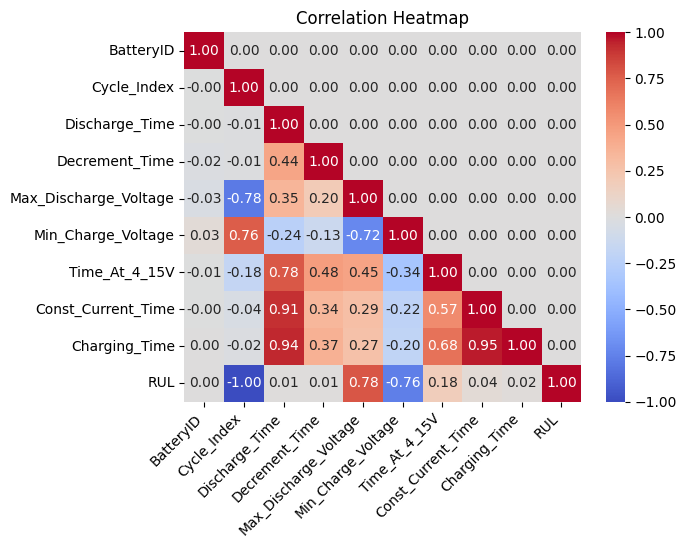

In [ ]:
# Corrrelation Heatmap with half of the data

ax = sns.heatmap(np.tril(df.corr()), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f"
            , xticklabels = df.columns
            , yticklabels = df.columns) 
ax.set_title('Correlation Heatmap')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

# **Data Split**

In [13]:
df.columns

Index(['BatteryID', 'Cycle_Index', 'Discharge_Time', 'Decrement_Time',
       'Max_Discharge_Voltage', 'Min_Charge_Voltage', 'Time_At_4_15V',
       'Const_Current_Time', 'Charging_Time', 'RUL'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["BatteryID","RUL"],axis=1)
                                                    , df.loc[:,"RUL"]
                                                    , test_size=0.2, random_state=42)

# Data Shape 
print("Train Data Shape:",X_train.shape,y_train.shape)
print("Test Data Shape:",X_test.shape,y_test.shape)

Train Data Shape: (12051, 8) (12051,)
Test Data Shape: (3013, 8) (3013,)


# **Model 00**

In [40]:
from sklearn.linear_model import LinearRegression 

# Initiate & Train the model
model_00 = LinearRegression()
model_00.fit(X_train, y_train)

# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error 
print(model_00.score(X_test, y_test))
print('MSE: ',mean_squared_error(y_test, model_00.predict(X_test)))
print('RMSE ',root_mean_squared_error(y_test, model_00.predict(X_test)))
print('R2: ',r2_score(y_test, model_00.predict(X_test)))

0.9994734493523346
MSE:  54.543070663859154
RMSE  7.385328067449621
R2:  0.9994734493523346


# **Reference**

- https://www.mdpi.com/1996-1073/11/5/1031
- https://www.kaggle.com/code/sasakitetsuya/remaining-useful-lifetime-prediction